## **INSURANCE DATA ANALYSIS**

**Stage 1. Sampling and Data Extraction**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
payments=pd.read_csv(r"D:\Analytics\All Projects\Insurance Data Analysis\payments.csv")
claims=pd.read_csv(r"D:\Analytics\All Projects\Insurance Data Analysis\claims.csv")
medical_checkups=pd.read_csv(r"D:\Analytics\All Projects\Insurance Data Analysis\medical_checkups.csv")
customer_policies=pd.read_csv(r"D:\Analytics\All Projects\Insurance Data Analysis\customer_policies.csv")

*LETS LOOK EACH DATASETS*

In [7]:
payments

,Payment ID,Policy ID,Year,Payment Amount,Payment Method,Missed Payment
0,10001_2019_P0,10001_2019,2019,108.33,Bank Transfer,0
1,10001_2019_P1,10001_2019,2019,108.33,Bank Transfer,0
2,10001_2019_P2,10001_2019,2019,108.33,Bank Transfer,0
3,10001_2019_P3,10001_2019,2019,108.33,Bank Transfer,0
4,10001_2019_P4,10001_2019,2019,108.33,Bank Transfer,0
...,...,...,...,...,...,...
232116,14999_2023_P8,14999_2023,2023,84.75,Credit Card,0
232117,14999_2023_P9,14999_2023,2023,84.75,Credit Card,0
232118,14999_2023_P10,14999_2023,2023,84.75,Credit Card,0
232119,14999_2023_P11,14999_2023,2023,NaN,Credit Card,0


In [8]:
claims

,Claim ID,Policy ID,Year,Claim Amount,Claim Status
0,10001_2019_C0,10001_2019,2019,3394,Approved
1,10003_2019_C0,10003_2019,2019,14003,Rejected
2,10003_2019_C1,10003_2019,2019,6770,Approved
3,10003_2019_C2,10003_2019,2019,9324,Pending
4,10005_2019_C0,10005_2019,2019,450851,Rejected
...,...,...,...,...,...
45353,14998_2023_C3,14998_2023,2023,6026,Approved
45354,14999_2023_C0,14999_2023,2023,14922,Approved
45355,14999_2023_C1,14999_2023,2023,13518,Approved
45356,14999_2023_C2,14999_2023,2023,7487,Rejected


In [76]:
medical_checkups

,Checkup ID,Policy ID,Year,BMI,Blood Pressure,Diabetes Risk
0,10006_2019_M,10006_2019,2019,26.36,NaN,Low
1,10007_2019_M,10007_2019,2019,31.00,Normal,Low
2,10010_2019_M,10010_2019,2019,NaN,Normal,Low
3,10017_2019_M,10017_2019,2019,18.86,Prehypertension,Low
4,10018_2019_M,10018_2019,2019,31.88,Normal,Low
...,...,...,...,...,...,...
12553,14984_2023_M,14984_2023,2023,25.55,Normal,NaN
12554,14985_2023_M,14985_2023,2023,NaN,Normal,Low
12555,14989_2023_M,14989_2023,2023,19.67,Normal,Low
12556,14992_2023_M,14992_2023,2023,33.82,NaN,Low


In [10]:
customer_policies

,Policy ID,Customer ID,Year,Policy Type,Premium,Deductible,Coverage Type,Premium Increase (%),Previous Year Claims,Previous Year Missed Payments,Churn
0,10001_2019,10001,2019,Auto,1300.0,NaN,Basic,8.0,1,0,1
1,10002_2019,10002,2019,Life,4229.0,2043.0,Standard,4.0,1,1,1
2,10003_2019,10003,2019,Auto,3433.0,603.0,Standard,13.0,2,0,1
3,10004_2019,10004,2019,Auto,4169.0,3478.0,Standard,5.0,1,0,0
4,10005_2019,10005,2019,Life,2538.0,2782.0,Premium,9.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
24995,14996_2023,14996,2023,Life,4245.0,4875.0,Standard,6.0,1,0,1
24996,14997_2023,14997,2023,Life,2664.0,749.0,Premium,16.0,0,0,1
24997,14998_2023,14998,2023,Life,NaN,2991.0,Standard,13.0,2,2,1
24998,14999_2023,14999,2023,Auto,1017.0,2700.0,Premium,1.0,1,2,1


*Q1: Identify the Distribution of Policy Records in the Payments Table*

In [77]:
unique_policies=payments['Policy ID'].nunique()
print('Total Unique Policies',unique_policies)

Total Unique Policies 25000


*Q2: Distribution of Payment Method in Payments.*

In [78]:
percentage=payments['Payment Method'].value_counts(normalize=True)*100
percentage

Payment Method
Credit Card      50.042866
Bank Transfer    29.661685
UPI              15.247220
Cash              5.048229
Name: proportion, dtype: float64

**Stage 2. Univariate Analysis**

*Q1: Analyze the Distribution of Premium Amounts.*

In [79]:
print(customer_policies['Premium'].describe())
skewness=(
    customer_policies['Premium'].dropna().skew()
)
print(f'Skewness:{skewness}')

count    23782.000000
mean      3649.248003
std       4816.515064
min       1000.000000
25%       2011.250000
50%       3021.500000
75%       4050.000000
max      49760.000000
Name: Premium, dtype: float64
Skewness:6.750191211791756


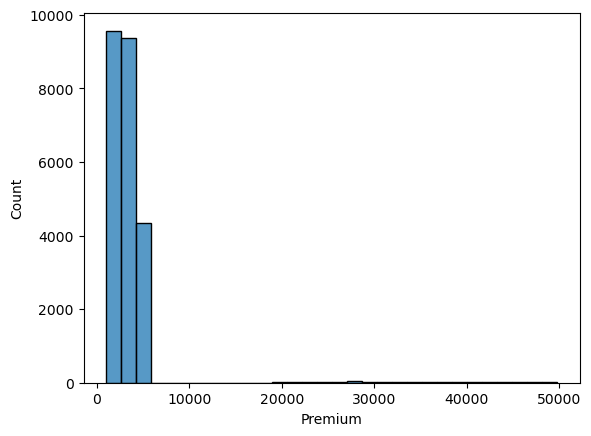

In [18]:
sns.histplot(data=customer_policies['Premium'].dropna(),bins=30)
plt.show()

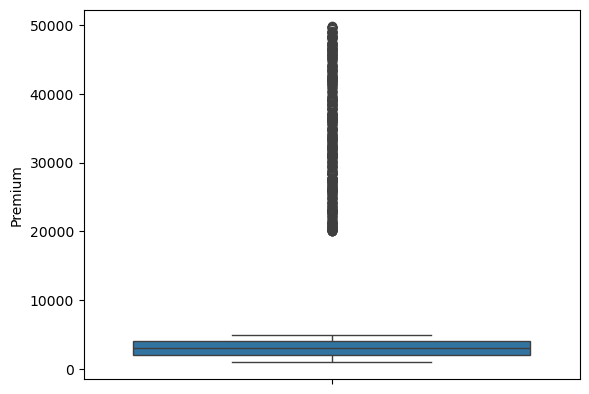

In [20]:
sns.boxplot(data=customer_policies['Premium'].dropna())
plt.show()

*Q2: Identify Missing Values in Medical Checkups Data.*

In [80]:
missing_data=pd.DataFrame({
    'Missing_Count':medical_checkups.isna().sum(),
    'Missing_percent':(medical_checkups.isna().sum()/len(medical_checkups))*100})
missing_data=missing_data[missing_data['Missing_Count']>0]
print(missing_data)

                Missing_Count  Missing_percent
BMI                       868         6.911929
Blood Pressure            888         7.071190
Diabetes Risk             889         7.079153


*Q3: Find Outliers in Claim Amounts.*

In [32]:
q1=claims['Claim Amount'].quantile(0.25)
q3=claims['Claim Amount'].quantile(0.75)
IQR= q3-q1
upper_bound=q3+1.5*IQR
lower_bound=q1-1.5*IQR
print(f'Lower_Bound: {lower_bound}')
print(f'Upper_Bound: {upper_bound}')
outliers=claims[(claims['Claim Amount']>upper_bound) | (claims['Claim Amount']<lower_bound)].value_counts().sum()
print(f'Total Outliers: {outliers}')

Lower_Bound: -6732.0
Upper_Bound: 22620.0
Total Outliers: 907


*Q4: Analyze Missed Payments.*

In [36]:
missed=payments['Missed Payment'].value_counts()
print('Missed Payment Count:')
print(missed)
missed_rate=payments['Missed Payment'].value_counts(normalize=True)*100
print('Missed Payment Rate:')
print(missed_rate)

Missed Payment Count:
Missed Payment
0    208958
1     23163
Name: count, dtype: int64
Missed Payment Rate:
Missed Payment
0    90.021153
1     9.978847
Name: proportion, dtype: float64


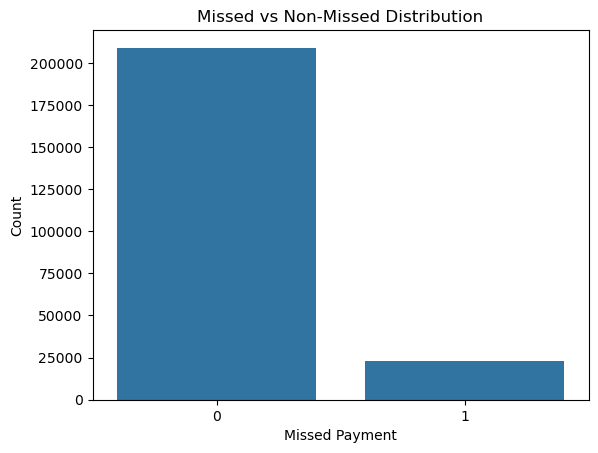

In [38]:
sns.countplot(data=payments,x='Missed Payment')
plt.title('Missed vs Non-Missed Distribution')
plt.xlabel('Missed Payment')
plt.ylabel('Count')
plt.show()

*Q5: Analyze Churn Rate Across Different Policy Types*

In [41]:
churn_rate=customer_policies.groupby('Policy Type')['Churn'].mean()*100
churn_rate

Policy Type
Auto      81.480889
Health    80.817009
Home      78.926905
Life      80.644503
Name: Churn, dtype: float64

*Q6: Compare Blood Pressure Levels in the Medical Checkups Table.*

In [81]:
type_count=medical_checkups['Blood Pressure'].value_counts(normalize=True)*100
type_count

Blood Pressure
Normal             59.922879
Prehypertension    30.308483
Hypertension        9.768638
Name: proportion, dtype: float64

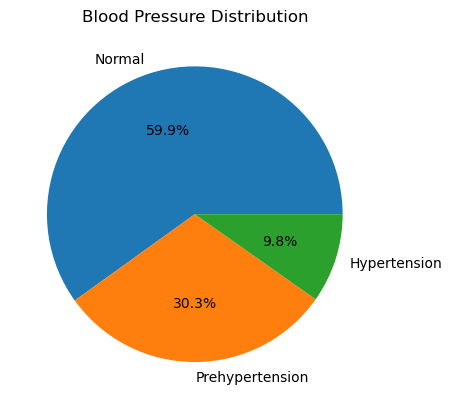

In [44]:
plt.pie(type_count,labels=type_count.index,autopct='%1.1f%%')
plt.title('Blood Pressure Distribution')
plt.show()

**Stage 3. Bivariate Analysis & Data Cleaning**

*Q1: Identify the Most Correlated Variables in the customer_policies dataset*

In [60]:
corr=customer_policies.select_dtypes(include='number').corr()

#---convert matrix to pairs
corr_pair=corr.unstack()
#---remove self pairs---
corr_pair=corr_pair[
    corr_pair.index.get_level_values(0) != corr_pair.index.get_level_values(1)]
corr_pair=corr_pair.drop_duplicates()
most_correlated=corr_pair.abs().sort_values(ascending=False)
print(most_correlated.head(3))


Previous Year Claims           Churn    0.432581
Previous Year Missed Payments  Churn    0.326336
Premium Increase (%)           Churn    0.227030
dtype: float64


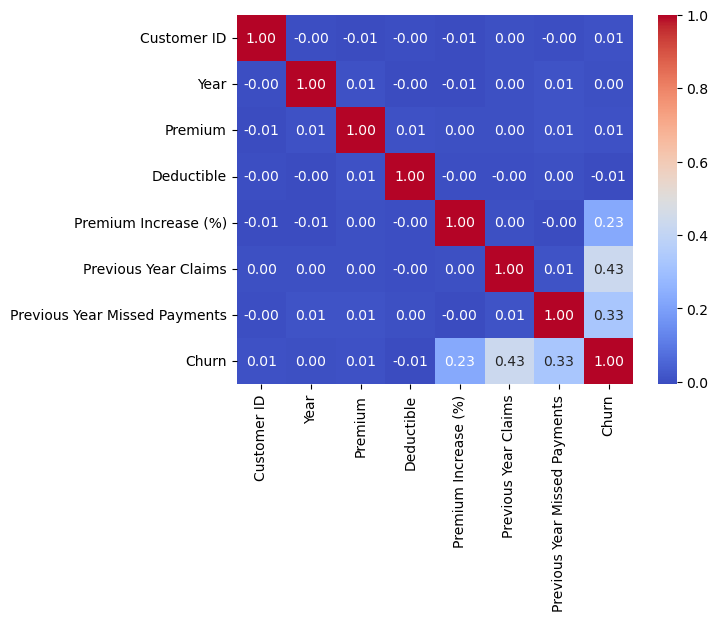

In [57]:
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.show()

*Q2: Analyze Churn Rate vs. Premium Amount.*

In [66]:
#---we will use qcut() for equal size bins---
customer_policies['bins']=pd.qcut(
    customer_policies['Premium'],q=5,labels=[1,2,3,4,5])

#---average churn rate---
churn_rate=(customer_policies.groupby('bins')['Churn'].mean()*100).reset_index(name='churn_rate')
churn_rate

C:\Users\sonali\AppData\Local\Temp\ipykernel_25464\2639906929.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate=(customer_policies.groupby('bins')['Churn'].mean()*100).reset_index(name='churn_rate')


,bins,churn_rate
0,1,80.811265
1,2,80.294118
2,3,80.909282
3,4,81.458903
4,5,80.845248


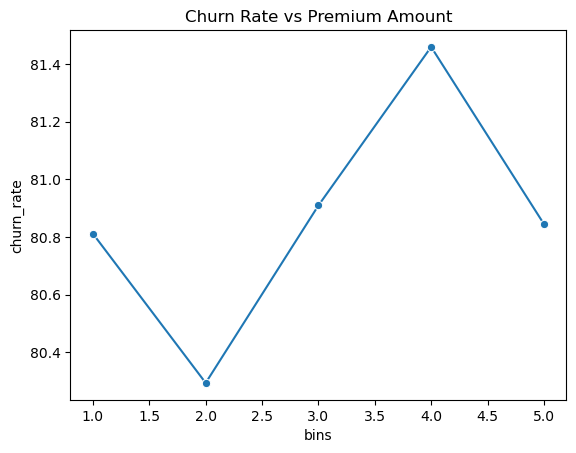

In [68]:
sns.lineplot(
    churn_rate,x='bins',y='churn_rate',marker='o')
plt.title('Churn Rate vs Premium Amount')
plt.show()

*Q3: Handle Missing Values in Medical Checkups.*

In [84]:
median_bmi=medical_checkups['BMI'].median()
medical_checkups['BMI']=medical_checkups['BMI'].fillna(median_bmi)
print(medical_checkups['BMI'].isna().sum())
mode_bp=medical_checkups['Blood Pressure'].mode()
medical_checkups['Blood Pressure']=medical_checkups['Blood Pressure'].fillna(median_bmi)
print(medical_checkups['Blood Pressure'].isna().sum())

0
0


*Q7: Handle missing values in the Premium Increase (%) of the customer_policies dataset.*

In [89]:
customer_policies['Premium Increase (%)'] = (
    customer_policies
    .groupby('Policy Type')['Premium Increase (%)']
    .transform(
        lambda x: x.fillna(x.mean())
    )
)
missing_values = (
    customer_policies['Premium Increase (%)']
    .isna()
    .sum()
)
print(f'Remaining Missing Values: {missing_values}')

Remaining Missing Values: 0


*Q8: Detect and Remove Outliers in Claim Amount.*

In [90]:
q1=claims['Claim Amount'].quantile(0.25)
q3=claims['Claim Amount'].quantile(0.75)
IQR= q3-q1
upper_bound=q3+1.5*IQR
lower_bound=q1-1.5*IQR

cleaned_claims=claims[claims['Claim Amount']<=upper_bound]
print(f'Original Dataset Length: {len(claims)}')
print(f'Cleaned Dataset Length: {len(cleaned_claims)}')

Original Dataset Length: 45358
Cleaned Dataset Length: 44451


**Stage 4. Advanced Bivariate Analysis**

*Q1: How Do Outliers Affect Claim Amounts?*

In [93]:
#--- before removing outliers in claim amount, the avg---
with_outlier=claims[claims['Claim Amount']>upper_bound]
avg_claim=cleaned_claims['Claim Amount'].mean()
avg_claim_outlier=with_outlier['Claim Amount'].mean()
print(f'Normal Claims average: {avg_claim}')
print(f'Outliers Avg Claim: {avg_claim_outlier}')

Normal Claims average: 7778.116690288182
Outliers Avg Claim: 301855.84454244765


*Q2: Time-Based Trends in Claims.*

In [96]:
claims['Year']=pd.to_datetime(claims['Year'],format='%Y')
time_based=claims.groupby('Year')['Claim Amount'].mean().reset_index()
time_based

,Year,Claim Amount
0,2019-01-01,13177.378528
1,2020-01-01,14185.246296
2,2021-01-01,13376.237845
3,2022-01-01,13616.798170
4,2023-01-01,13922.473707


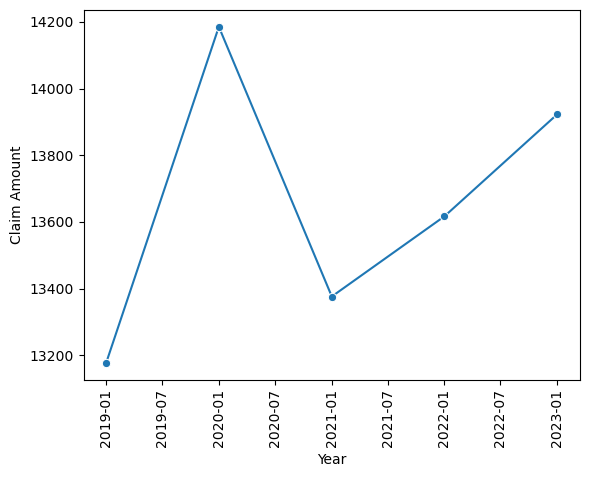

In [99]:
sns.lineplot(time_based,x='Year',y='Claim Amount',marker='o')
plt.xticks(rotation=90)
plt.show()

In [144]:
customer_policies

,Policy ID,Customer ID,Year,Policy Type,Premium,Deductible,Coverage Type,Premium Increase (%),Previous Year Claims,Previous Year Missed Payments,Churn,Premium Increase,pbins,High_Deductible,bins,High_Churn_Risk_x,High_Churn_Risk_y,High_Churn_Risk
0,10001_2019,10001,2019,Auto,1300.0,3131.057903,Basic,8.0,1,0,1,8.0,4,1,1,0.0,0.0,0.0
1,10002_2019,10002,2019,Life,4229.0,2043.000000,Standard,4.0,1,1,1,4.0,2,0,8,1.0,1.0,1.0
2,10003_2019,10003,2019,Auto,3433.0,603.000000,Standard,13.0,2,0,1,13.0,7,0,7,1.0,1.0,1.0
3,10004_2019,10004,2019,Auto,4169.0,3478.000000,Standard,5.0,1,0,0,5.0,3,1,8,1.0,1.0,1.0
4,10005_2019,10005,2019,Life,2538.0,2782.000000,Premium,9.0,0,0,0,9.0,5,0,4,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,14996_2023,14996,2023,Life,4245.0,4875.000000,Standard,6.0,1,0,1,6.0,3,1,8,1.0,1.0,1.0
24996,14997_2023,14997,2023,Life,2664.0,749.000000,Premium,16.0,0,0,1,16.0,9,0,5,1.0,1.0,1.0
24997,14998_2023,14998,2023,Life,NaN,2991.000000,Standard,13.0,2,2,1,13.0,7,1,NaN,NaN,NaN,NaN
24998,14999_2023,14999,2023,Auto,1017.0,2700.000000,Premium,1.0,1,2,1,1.0,1,0,1,0.0,0.0,0.0


*Q7: How Premium Increase % Affects Churn?*

  pbins      Churn
0     1  65.817049
1     2  72.038510
2     3  74.820144
3     4  78.541667
4     5  81.364073
5     6  83.808096
6     7  86.537653
7     8  88.953248
8     9  89.907873
9    10  93.542977


C:\Users\sonali\AppData\Local\Temp\ipykernel_25464\403026564.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result=(customer_policies.groupby('pbins')['Churn'].mean()*100).reset_index()


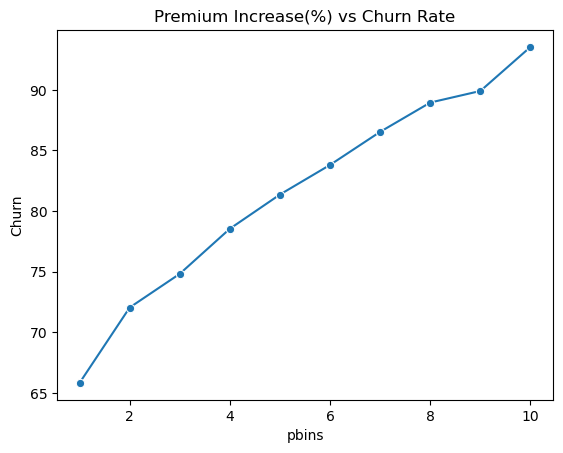

In [106]:
customer_policies['pbins']=pd.qcut(customer_policies['Premium Increase (%)'],q=10,labels=[1,2,3,4,5,6,7,8,9,10])
result=(customer_policies.groupby('pbins')['Churn'].mean()*100).reset_index()
print(result)

#plot
sns.lineplot(result,x='pbins',y='Churn',marker='o')
plt.title('Premium Increase(%) vs Churn Rate')
plt.show()

**Stage 5. Feature Engineering**

*Q1: Create Aggregated Customer Metrics.*

In [115]:
res1=payments.groupby('Policy ID').agg(total_payment=('Payment Amount', 'sum'),
        missed_payment_rate=('Missed Payment', 'mean')).reset_index()
res2=claims.groupby('Policy ID')['Claim Amount'].sum().reset_index(name='total_claims')

In [117]:
#---Merge in Customer Policies Table
merged=customer_policies.merge(res1,on='Policy ID',how='left')
merged=merged.merge(res2,on='Policy ID',how='left')
merged[['Policy ID','total_claims','total_payment','missed_payment_rate']]

,Policy ID,total_claims,total_payment,missed_payment_rate
0,10001_2019,3394.0,1083.30,0.083333
1,10002_2019,NaN,3876.62,0.000000
2,10003_2019,30097.0,3432.96,0.000000
3,10004_2019,NaN,3474.20,0.166667
4,10005_2019,461390.0,2538.00,0.000000
...,...,...,...,...
24995,14996_2023,31542.0,3537.50,0.000000
24996,14997_2023,4932.0,1998.00,0.000000
24997,14998_2023,37942.0,2452.00,0.000000
24998,14999_2023,35927.0,932.25,0.083333


*Q2: Generate Ratio-Based Features.*

In [125]:
claim_count=claims.groupby('Policy ID')['Claim Amount'].sum().reset_index(name='total_claim')
merged=customer_policies.merge(claim_count,on='Policy ID',how='left')
merged['claim_to_premium']=merged['total_claim']/merged['Premium']

res1=payments.groupby('Policy ID')['Payment Amount'].sum().reset_index(name='total_payment')
merged=merged.merge(res1,on='Policy ID',how='left')
merged['payment_to_premium']=merged['total_payment']/merged['Premium']

merged[['Policy ID','claim_to_premium','payment_to_premium']]

,Policy ID,claim_to_premium,payment_to_premium
0,10001_2019,2.610769,0.833308
1,10002_2019,NaN,0.916675
2,10003_2019,8.766968,0.999988
3,10004_2019,NaN,0.833341
4,10005_2019,181.792750,1.000000
...,...,...,...
24995,14996_2023,7.430389,0.833333
24996,14997_2023,1.851351,0.750000
24997,14998_2023,NaN,NaN
24998,14999_2023,35.326450,0.916667


*Q3: Introduce Flags for Business Insights.*

In [137]:
mean_deductible=customer_policies['Deductible'].mean()
customer_policies['Deductible']=customer_policies['Deductible'].fillna(mean_deductible)

median_ded=customer_policies['Deductible'].median()
def deductible(x):
    if x>median_ded:
        return 1
    else:
        return 0

customer_policies['High_Deductible']=customer_policies['Deductible'].apply(deductible)

In [141]:
#---we will use qcut() for equal size bins---
customer_policies['bins']=pd.qcut(
    customer_policies['Premium'],q=10,labels=[1,2,3,4,5,6,7,8,9,10])

#---average churn rate---
churn_rate=(customer_policies.groupby('bins',observed=True)['Churn'].mean()*100).reset_index(name='churn_rate')
churn_rate['High_Churn_Risk']=(churn_rate['churn_rate']>80).astype(int)
customer_policies = customer_policies.merge(
    churn_rate[['bins', 'High_Churn_Risk']],
    on='bins',
    how='left'
)
output = customer_policies[
    [
        'Policy ID',
        'High_Deductible',
        'High_Churn_Risk'
    ]
]
print(output)

        Policy ID  High_Deductible  High_Churn_Risk
0      10001_2019                1              0.0
1      10002_2019                0              1.0
2      10003_2019                0              1.0
3      10004_2019                1              1.0
4      10005_2019                0              1.0
...           ...              ...              ...
24995  14996_2023                1              1.0
24996  14997_2023                0              1.0
24997  14998_2023                1              NaN
24998  14999_2023                0              0.0
24999  15000_2023                1              1.0

[25000 rows x 3 columns]


*Q4: Create Derived Features Based on Trends.*

In [150]:
# Merge datasets
merged_df = customer_policies.merge(
    claims,
    on='Policy ID',
    how='left'
)
# Sort values
merged_df = merged_df.sort_values(
    by=['Policy ID', 'Year_x']
)
# Rolling 3-year average
merged_df['Rolling_3yr_Claim_Avg'] = (
    merged_df
    .groupby('Policy ID')['Claim Amount']
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)
# Year-over-year premium growth
merged_df['Premium_Growth_YoY'] = (
    merged_df
    .groupby('Policy ID')['Premium']
    .pct_change()
    * 100
)
# Output
print(
    merged_df[
        [
            'Policy ID',
            'Year_x',
            'Rolling_3yr_Claim_Avg',
            'Premium_Growth_YoY'
        ]
    ]
)


        Policy ID  Year_x  Rolling_3yr_Claim_Avg  Premium_Growth_YoY
0      10001_2019    2019            3394.000000                 NaN
10037  10001_2020    2020                    NaN                 NaN
20282  10001_2021    2021           14411.000000                 NaN
20283  10001_2021    2021            9522.000000                 0.0
30544  10001_2022    2022                    NaN                 NaN
...           ...     ...                    ...                 ...
10036  15000_2019    2019            5207.666667                 0.0
20281  15000_2020    2020                    NaN                 NaN
30543  15000_2021    2021           10497.000000                 NaN
40741  15000_2022    2022                    NaN                 NaN
51011  15000_2023    2023            5543.000000                 NaN

[51012 rows x 4 columns]


C:\Users\sonali\AppData\Local\Temp\ipykernel_25464\3108619218.py:26: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()
